In [1]:
KEYPOINT_NAMES = [
    "nose",
    "left_eye",
    "right_eye",
    "left_shoulder", "right_shoulder",
    "left_elbow", "right_elbow",
    "left_wrist", "right_wrist",
    "left_index", "right_index",
    "left_thumb", "right_thumb",
    "left_hip", "right_hip",
    "left_knee", "right_knee",
    "left_ankle", "right_ankle",
    "left_heel", "right_heel",
    "left_foot_index", "right_foot_index"
]

# graph edges
EDGES = [
    (0,1), (0,2),                     # nose -> eyes
    (3,4),                             # shoulders
    (3,5), (5,7), (7,9),               # left arm
    (4,6), (6,8), (8,10),              # right arm
    (11,12),                           # hips
    (11,13), (13,15), (15,17),         # left leg
    (12,14), (14,16), (16,18),         # right leg
    (17,19), (18,20)                   # feet
]


In [2]:
import numpy as np

def normalize_pose(points):
    """
    points: np.array shape (23, 2)
    """

    pts = points.copy().astype(float)

    # centre
    left_hip = pts[11]
    right_hip = pts[12]
    root = (left_hip + right_hip) / 2
    pts -= root

    # scale
    left_sh = pts[3]
    right_sh = pts[4]
    shoulder_dist = np.linalg.norm(left_sh - right_sh)

    if shoulder_dist < 1e-6:
        shoulder_dist = 1e-6

    pts /= shoulder_dist

    # orientation
    dx = right_sh[0] - left_sh[0]
    dy = right_sh[1] - left_sh[1]
    theta = np.arctan2(dy, dx)

    R = np.array([
        [ np.cos(theta),  np.sin(theta)],
        [-np.sin(theta),  np.cos(theta)]
    ])

    pts = pts @ R.T

    return pts


In [3]:
import matplotlib.pyplot as plt

def plot_pose(points, edges, title="Pose"):
    plt.figure(figsize=(5,5))
    for (i,j) in edges:
        if not np.any(np.isnan(points[i])) and not np.any(np.isnan(points[j])):
            plt.plot([points[i,0], points[j,0]],
                     [points[i,1], points[j,1]], 'k-', linewidth=2)

    plt.scatter(points[:,0], points[:,1], c='red', s=40)
    plt.gca().invert_yaxis()
    plt.title(title)
    plt.axis('equal')
    plt.show()


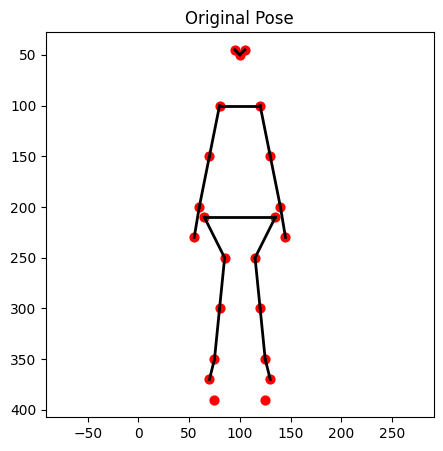

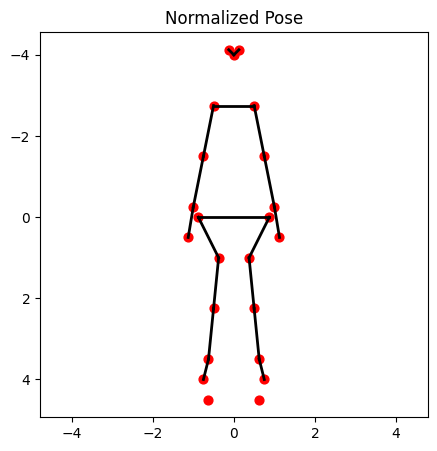

In [ ]:

example_pose = np.array([
    [
        0.5024232633279483,
        0.2625
      ],
      [
        0.5218093699515347,
        0.25555555555555554
      ],
      [
        0.4862681744749596,
        0.25416666666666665
      ],
      [
        0.5508885298869144,
        0.34305555555555556
      ],
      [
        0.44749596122778673,
        0.3416666666666667
      ],
      [
        0.6090468497576736,
        0.2222222222222222
      ],
      [
        0.40387722132471726,
        0.2125
      ],
      [
        0.5250403877221325,
        0.13055555555555556
      ],
      [
        0.49434571890145396,
        0.125
      ],
      [
        0.5153473344103393,
        0.05694444444444444
      ],
      [
        0.5024232633279483,
        0.058333333333333334
      ],
      [
        0.5218093699515347,
        0.1
      ],
      [
        0.4911147011308562,
        0.09583333333333334
      ],
      [
        0.5508885298869144,
        0.5430555555555555
      ],
      [
        0.4410339256865913,
        0.5402777777777777
      ],
      [
        0.7253634894991923,
        0.5930555555555556
      ],
      [
        0.4894991922455573,
        0.7166666666666667
      ],
      [
        0.5218093699515347,
        0.6194444444444445
      ],
      [
        0.5169628432956381,
        0.9027777777777778
      ],
      [
        0.481421647819063,
        0.6069444444444444
      ],
      [
        0.5363489499192245,
        0.9305555555555556
      ],
      [
        0.49596122778675283,
        0.6833333333333333
      ],
      [
        0.49596122778675283,
        0.9416666666666667
      ]
    ])
  

# визуализация исходной позы
plot_pose(example_pose, EDGES, title="Original Pose")

# нормализация
norm_pose = normalize_pose(example_pose)

# визуализация нормализованной позы
plot_pose(norm_pose, EDGES, title="Normalized Pose")
